# XGBoost

## Data Preparation

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn import preprocessing
from xgboost import XGBClassifier 

In [2]:
XGBOOST_OUTPUT_DIR = Path("../../../reports/trained_xgboost/cross_validation_20days")

XGBOOST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
data = pd.read_csv('../../../data/labeled_dataset.csv')

In [4]:
data['Date'] = pd.to_datetime(data['Date'])

In [5]:
data.columns

Index(['Date', 'GSPC', 'VIX', 'SPY Volume', 'GDP', 'Core_Inflation',
       'Unemployment', 'M2', 'Return', 'Return_5d', 'Return_20d',
       'Return_Smooth', 'RSI_14', 'MACD_Line', 'MACD_Signal', 'MACD_Hist',
       'year', 'quarter', 'GDP_YoY', 'month', 'Core_Inflation_YoY', 'M2_YoY',
       'Peak', 'Drawdown', 'VIX_Change', 'VIX_Change_5d', 'regime', 'segment'],
      dtype='str')

In [6]:
data.describe()

,Date,GSPC,VIX,SPY Volume,GDP,Core_Inflation,Unemployment,M2,Return,Return_5d,...,quarter,GDP_YoY,month,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,segment
count,8066,8066.000000,8066.000000,8.066000e+03,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,...,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000,8066.000000
mean,2010-02-01 02:29:04.210265,2019.295843,19.723230,8.589037e+07,17170.979583,90.894071,5.538718,10353.092165,0.000400,0.001953,...,2.511654,0.025600,6.535953,0.020431,0.060607,2228.514370,-0.110974,0.001169,0.004689,51.914208
min,1994-01-27 00:00:00,438.920013,9.140000,5.200000e+03,10939.116000,66.902000,3.400000,3474.900000,-0.119841,-0.183401,...,1.000000,-0.084695,1.000000,0.006256,-0.046910,477.049988,-0.567754,-18.710003,-26.379997,0.000000
25%,2002-01-30 06:00:00,1102.489990,14.010000,1.955088e+07,14372.785000,76.871000,4.300000,5460.900000,-0.004530,-0.009653,...,2.000000,0.018667,4.000000,0.015199,0.042003,1527.459961,-0.184359,-0.690001,-1.400000,28.000000
50%,2010-02-02 12:00:00,1374.145020,17.900000,6.509505e+07,16872.266000,89.446000,5.000000,8523.500000,0.000673,0.003542,...,3.000000,0.026013,7.000000,0.018279,0.057890,1565.150024,-0.057564,-0.075001,-0.120001,53.000000
75%,2018-02-05 18:00:00,2626.942505,23.110001,1.136950e+08,19882.352000,101.198000,6.100000,13919.000000,0.005842,0.014946,...,4.000000,0.034949,10.000000,0.021915,0.071864,2872.870117,-0.011118,0.580000,1.190000,76.000000
max,2026-02-13 00:00:00,6978.600098,82.690002,8.710263e+08,24026.834000,127.422000,14.800000,22411.000000,0.115800,0.191112,...,4.000000,0.123857,12.000000,0.057016,0.281678,6978.600098,0.000000,24.860001,35.850002,105.000000
std,NaN,1460.854641,8.015070,8.985808e+07,3513.615972,16.055677,1.783561,5940.148670,0.011737,0.023961,...,1.115822,0.020355,3.430906,0.009300,0.043241,1472.117991,0.123453,1.720643,3.254432,30.565074


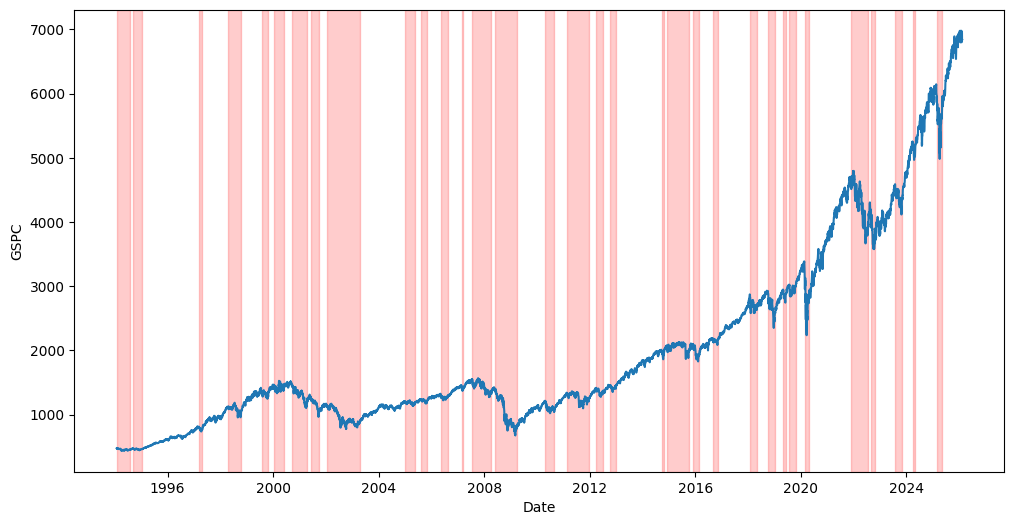

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='GSPC', data=data)
plt.fill_between(
    data['Date'], 
    0, 1, 
    where=(data['regime'] == 'bear'),             
    color='red',                              
    alpha=0.2,                                
    transform=plt.gca().get_xaxis_transform(), 
    label='Bear Regime'
)

In [8]:
data['regime_binary']= np.where(data['regime']=='bull',1,0)

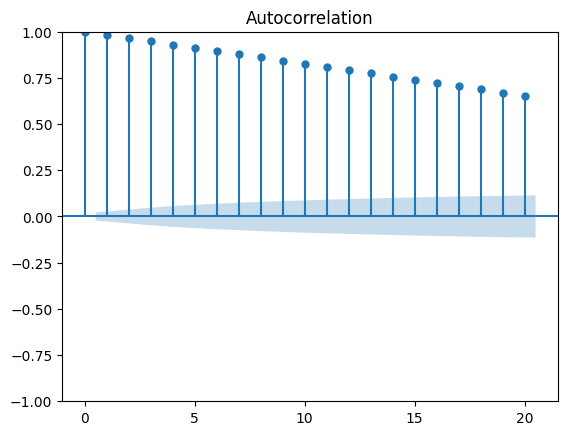

In [9]:
plot_acf(data['regime_binary'], lags=20)
plt.show()

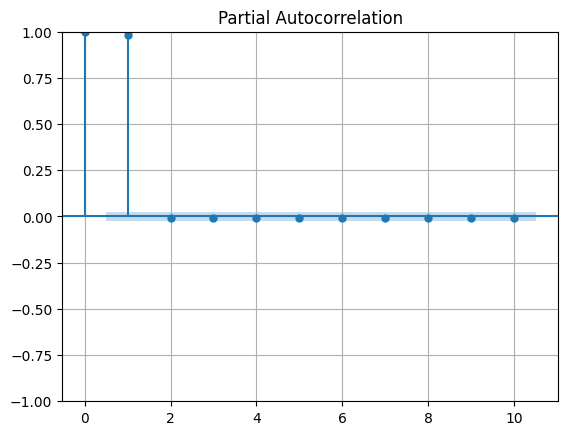

In [10]:
plot_pacf(data['regime_binary'], lags=10)
plt.grid()
plt.show()
### AR(1) model

In [11]:
data['Risk_Adj_Return_20d'] = data['Return_20d'] / (data['VIX'] + 0.00001)

data['SPY_Volume_20d_MA'] = data['SPY Volume'].rolling(window=20).mean()

data['Relative_Volume'] = data['SPY Volume'] / data['SPY_Volume_20d_MA']

data['MACD_Hist_Accel'] = data['MACD_Hist'] - data['MACD_Hist'].shift(1)

data = data.drop(columns=['SPY_Volume_20d_MA']).dropna()

In [12]:
data['lagged_target_20'] = data['regime_binary'].shift(-20)

In [13]:
data_1 = data.dropna(subset=['lagged_target_20']) 

In [14]:
stationary_features = [
    'Return', 'Return_5d', 'Return_20d', 'Return_Smooth', 
    'RSI_14', 'MACD_Hist', 'Drawdown', 
    'VIX', 'VIX_Change', 'VIX_Change_5d', 
    'GDP_YoY', 'Core_Inflation_YoY', 'M2_YoY', 'Unemployment',
    'Risk_Adj_Return_20d','Relative_Volume',
    'MACD_Hist_Accel'
]

In [15]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

def station_test(df):
    for col in df.columns:
        res = adfuller(df[col].dropna())
        print('p_value =', np.round(res[1], 5), 'for', col)

station_test(data[stationary_features])


p_value = 0.0 for Return
p_value = 0.0 for Return_5d
p_value = 0.0 for Return_20d
p_value = 0.0 for Return_Smooth
p_value = 0.0 for RSI_14
p_value = 0.0 for MACD_Hist
p_value = 0.12044 for Drawdown
p_value = 0.0 for VIX
p_value = 0.0 for VIX_Change
p_value = 0.0 for VIX_Change_5d
p_value = 8e-05 for GDP_YoY
p_value = 0.29915 for Core_Inflation_YoY
p_value = 0.00489 for M2_YoY
p_value = 0.01537 for Unemployment
p_value = 0.0 for Risk_Adj_Return_20d
p_value = 0.0 for Relative_Volume
p_value = 0.0 for MACD_Hist_Accel


<Axes: xlabel='Date', ylabel='Core_Inflation_YoY'>

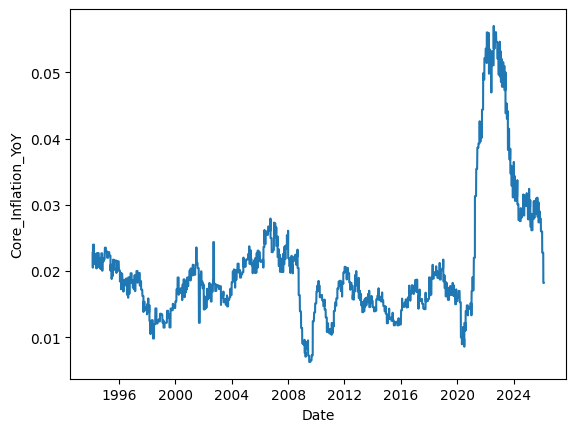

In [16]:
sns.lineplot(x='Date', y='Core_Inflation_YoY', data=data)

<Axes: xlabel='Date', ylabel='Drawdown'>

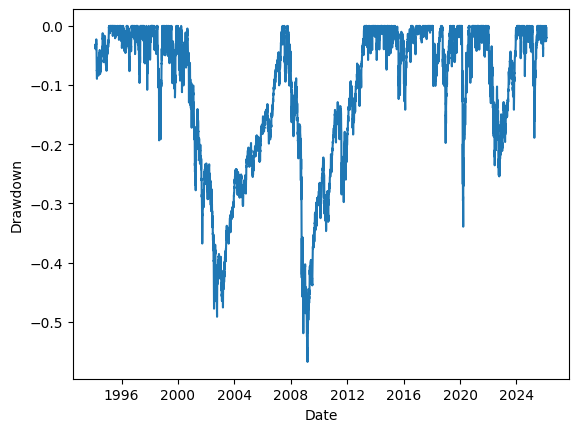

In [17]:
sns.lineplot(x='Date', y='Drawdown', data=data)

In [18]:
X = data_1[stationary_features]
y = data_1['lagged_target_20']

<Axes: >

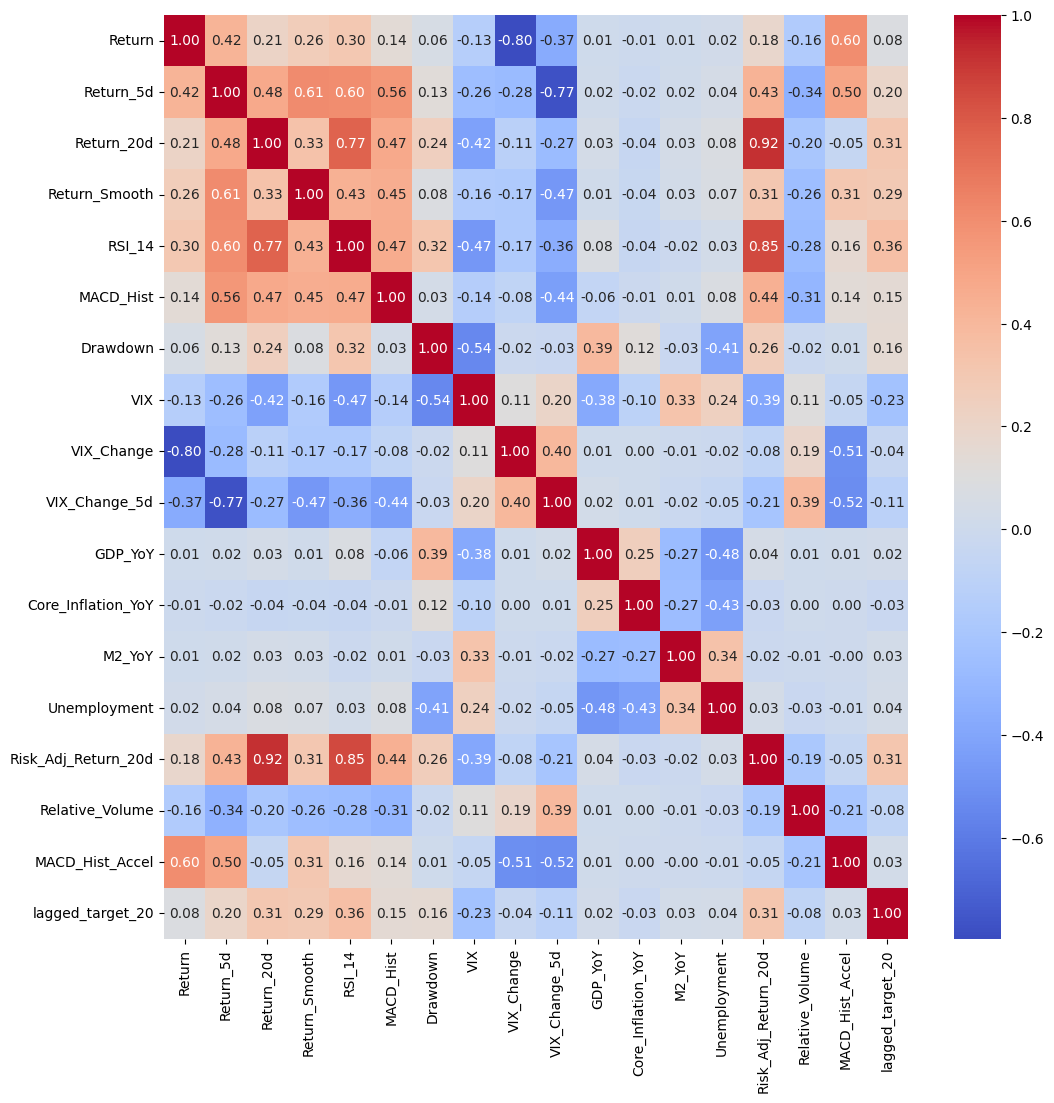

In [19]:
plt.figure(figsize=(12, 12))
cov_matrix = data_1[stationary_features + ['lagged_target_20']].corr()
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap='coolwarm')

## Cross Validation

In [20]:
total_rows = len(data_1)

train_end = int(total_rows * 0.70)
val_end = int(total_rows * 0.85) 


scaler = preprocessing.StandardScaler()

X_train = X.iloc[:train_end]
X_train = scaler.fit_transform(X_train)
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
X_val = scaler.transform(X_val)
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
X_test = scaler.transform(X_test)
y_test = y.iloc[val_end:]

In [21]:
print(f"Total trading days: {total_rows}")
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

Total trading days: 8027
Training shapes: X=(5618, 17), y=(5618,)
Validation shapes: X=(1204, 17), y=(1204,)
Test shapes: X=(1205, 17), y=(1205,)


In [22]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, confusion_matrix, roc_curve

# CV is done on TRAINING DATA ONLY (70%)
# Validation set is kept completely separate for final evaluation
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

X_cv = X.iloc[:train_end]   # Training data only
y_cv = y.iloc[:train_end]

In [23]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=0),
    param_grid,
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_cv, y_cv)

print("Best params:   ", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params:    {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV ROC-AUC: 0.5417870293637976


In [24]:
# Show top 10 parameter combinations ranked by mean CV ROC-AUC
cv_results_xgb = pd.DataFrame(grid_search.cv_results_)
cv_summary_xgb = (
    cv_results_xgb[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
)
print(cv_summary_xgb.head(10).to_string(index=False))

                                                      params  mean_test_score  std_test_score  rank_test_score
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}         0.541787        0.071479                1
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}         0.530262        0.062616                2
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}         0.519090        0.057278                3
 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}         0.517243        0.076328                4
 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}         0.513856        0.078474                5
 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}         0.507656        0.075525                6
 {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}         0.503277        0.114507                7
 {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 150}         0.499720        0.104251                8
 

## Training

In [25]:
best_params = grid_search.best_params_

xgb_final = XGBClassifier(**best_params, random_state=0)
xgb_final.fit(X_train, y_train)

print("Retrained with best params:", best_params)

Retrained with best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


## Testing on Validation Set

In [26]:
y_pred_prob_test_xgb = xgb_final.predict_proba(X_val)[:, 1]

In [27]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob_test_xgb)
j_scores = tpr - fpr
best_threshold_xgb_test = thresholds[np.argmax(j_scores)]

# Binary predictions
y_pred_test_xgb = (y_pred_prob_test_xgb >= best_threshold_xgb_test).astype(int)

In [28]:
acc_test = accuracy_score(y_val, y_pred_test_xgb)
roc_auc_test = roc_auc_score(y_val, y_pred_prob_test_xgb)
prec_test = precision_score(y_val, y_pred_test_xgb)
rec_test = recall_score(y_val, y_pred_test_xgb)

print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test ROC-AUC: {roc_auc_test:.4f}")
print(f"Test Precision: {prec_test:.4f}")
print(f"Test Recall: {rec_test:.4f}")

Test Accuracy: 0.6927
Test ROC-AUC: 0.7659
Test Precision: 0.8825
Test Recall: 0.6814


<Axes: >

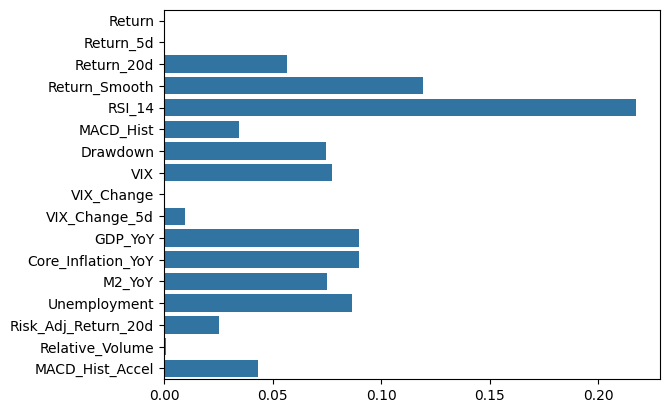

In [34]:
names = ['const'] + list(X.columns)
sns.barplot(x=xgb_final.feature_importances_, y=names[1:])
# sns.barplot(x=xgb_final.feature_importances_, y=stationary_features)

Best Threshold (Youden's J): 0.5445


<Axes: >

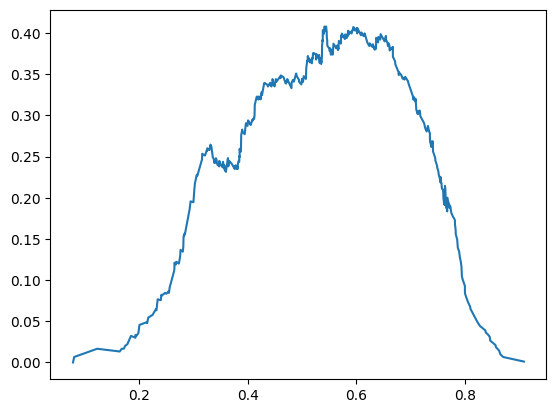

In [30]:
print(f"Best Threshold (Youden's J): {best_threshold_xgb_test:.4f}")
sns.lineplot(x=thresholds, y=j_scores)

<Axes: xlabel='col_0', ylabel='lagged_target_20'>

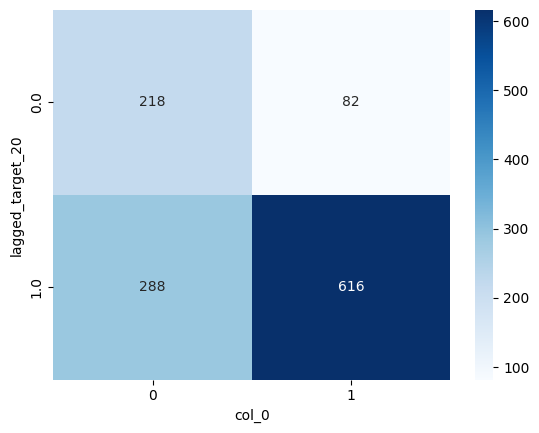

In [31]:
# Confusion matrix
sns.heatmap(pd.crosstab(y_val, y_pred_test_xgb), annot=True, fmt='d', cmap='Blues')

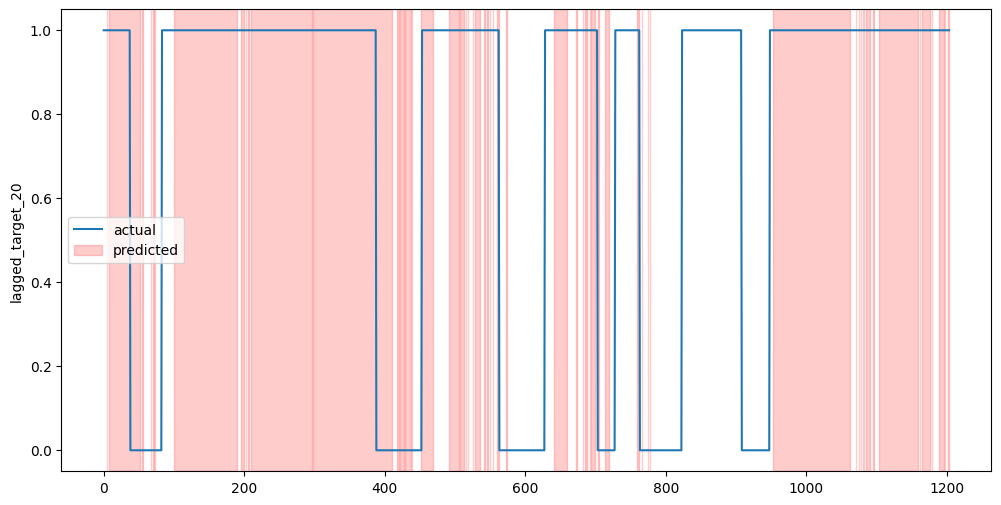

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val.reset_index(drop=True), label='actual')
plt.fill_between(
    range(len(X_val)),
    0, 1, 
    where=(y_pred_test_xgb == 1),              
    color='red',                              
    alpha=0.2,                                 
    transform=plt.gca().get_xaxis_transform(), 
    label='predicted'
)

plt.legend()

In [33]:
cv_summary_export = cv_summary_xgb.copy()
cv_summary_export.to_csv(XGBOOST_OUTPUT_DIR / "cv_summary.csv", index=False)

test_dates = data_1["Date"].iloc[train_end:val_end].reset_index(drop=True)

xgb_test_metrics = pd.DataFrame([
    {
        "model": "xgboost",
        "target": "regime_binary",
        "best_params": str(best_params),
        "accuracy": acc_test,
        "roc_auc": roc_auc_test,
        "precision": prec_test,
        "recall": rec_test,
        "best_threshold": best_threshold_xgb_test,
    }
])
xgb_test_metrics.to_csv(XGBOOST_OUTPUT_DIR / "test_metrics.csv", index=False)

xgb_predictions = pd.DataFrame({
    "Date": test_dates,
    "y_true": y_val.reset_index(drop=True),
    "y_pred": pd.Series(y_pred_test_xgb).reset_index(drop=True),
    "y_pred_prob": pd.Series(y_pred_prob_test_xgb).reset_index(drop=True),
    "model": "xgboost",
})
xgb_predictions.to_csv(XGBOOST_OUTPUT_DIR / "predictions.csv", index=False)

xgb_confusion = pd.DataFrame(
    confusion_matrix(y_val, y_pred_test_xgb),
    index=["actual_bear", "actual_bull"],
    columns=["pred_bear", "pred_bull"],
)
xgb_confusion.to_csv(XGBOOST_OUTPUT_DIR / "confusion_matrix.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(xgb_confusion, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(XGBOOST_OUTPUT_DIR / "confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.close()

plt.figure(figsize=(12, 6))
sns.lineplot(x=range(len(X_val)), y=y_val.reset_index(drop=True), label='actual')
plt.fill_between(
    range(len(X_val)),
    0,
    1,
    where=(pd.Series(y_pred_test_xgb).reset_index(drop=True) == 1),
    color='red',
    alpha=0.2,
    label='predicted',
)
plt.title('XGBoost Prediction Timeline')
plt.xlabel('Validation Observation')
plt.ylabel('Regime')
plt.legend()
plt.tight_layout()
plt.savefig(XGBOOST_OUTPUT_DIR / "prediction_timeline.png", dpi=180, bbox_inches="tight")
plt.close()

print(f"Saved XGBoost outputs to {XGBOOST_OUTPUT_DIR}")

Saved XGBoost outputs to ../../../reports/trained_xgboost/cross_validation_20days
